# Iris Classification - TensorFlow Full-Batch GD (FBGB) vs Gauss-Newton (GN)

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

try:
    tf.config.set_visible_devices([], 'GPU')
    print("GPU dimatikan, TensorFlow pakai CPU.")
except:
    pass

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

seed = 42
np.random.seed(seed)
tf.keras.utils.set_random_seed(seed)

print('TensorFlow version:', tf.__version__)

2026-04-08 03:48:27.139906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775620107.323978      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775620107.374574      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775620107.785668      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775620107.785705      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775620107.785707      24 computation_placer.cc:177] computation placer alr

GPU dimatikan, TensorFlow pakai CPU.
TensorFlow version: 2.19.0


In [2]:

# Load and preprocess Iris dataset
iris = load_iris()
X = iris.data.astype('float32')
y_int = iris.target.astype('int32')
class_names = iris.target_names.tolist()
y = tf.keras.utils.to_categorical(y_int, num_classes=3).astype('float32')

X_train, X_test, y_train, y_test, y_train_int, y_test_int = train_test_split(
    X, y, y_int,
    test_size=0.2,
    random_state=seed,
    stratify=y_int
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype('float32')
X_test = scaler.transform(X_test).astype('float32')

X_train_tf = tf.convert_to_tensor(X_train)
X_test_tf = tf.convert_to_tensor(X_test)
y_train_tf = tf.convert_to_tensor(y_train)
y_test_tf = tf.convert_to_tensor(y_test)

print('Train shape:', X_train_tf.shape, y_train_tf.shape)
print('Test shape :', X_test_tf.shape, y_test_tf.shape)
print('Classes    :', class_names)


Train shape: (120, 4) (120, 3)
Test shape : (30, 4) (30, 3)
Classes    : ['setosa', 'versicolor', 'virginica']


In [3]:
# Model sesuai PDF: 4 -> 8(ReLU) -> 6(ReLU) -> 3(Softmax)
def make_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4,)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(6, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax'),
    ])

loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=False)


def accuracy_from_probs(y_true_onehot, probs):
    y_true = tf.argmax(y_true_onehot, axis=1)
    y_pred = tf.argmax(probs, axis=1)
    return float(tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred), tf.float32)).numpy())


def evaluate_model(model):
    train_probs = model(X_train_tf, training=False)
    test_probs = model(X_test_tf, training=False)
    return {
        'train_loss': float(loss_fn(y_train_tf, train_probs).numpy()),
        'train_acc': accuracy_from_probs(y_train_tf, train_probs),
        'test_acc': accuracy_from_probs(y_test_tf, test_probs),
    }

base_model = make_model()
_ = base_model(X_train_tf[:1])
base_weights = base_model.get_weights()

param_count = np.sum([np.prod(v.shape) for v in base_model.trainable_variables])
print('Total parameters:', int(param_count))
print('Initial metrics :', evaluate_model(base_model))
base_model.summary()


Total parameters: 115
Initial metrics : {'train_loss': 1.1305683851242065, 'train_acc': 0.4416666626930237, 'test_acc': 0.4333333373069763}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115 (460.00 B)

 Trainable params: 115 (460.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Full-Batch Gradient Descent (manual update with TensorFlow autograd)
def train_fbgd(initial_weights, epochs=120, lr=0.1):
    model = make_model()
    _ = model(X_train_tf[:1])
    model.set_weights(initial_weights)

    history = []
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        with tf.GradientTape() as tape:
            probs = model(X_train_tf, training=True)
            loss = loss_fn(y_train_tf, probs)
        grads = tape.gradient(loss, model.trainable_variables)

        for var, grad in zip(model.trainable_variables, grads):
            var.assign_sub(lr * grad)

        metrics = evaluate_model(model)
        metrics['epoch'] = epoch
        history.append(metrics)

    duration = time.perf_counter() - start
    return model, pd.DataFrame(history), duration


In [5]:
# Gauss-Newton sesuai PDF
# Delta theta = (J^T J + lambda I)^(-1) J^T r
# dengan r = y - y_hat, J = d(y_hat)/d(theta)

def flatten_variables(variables):
    return tf.concat([tf.reshape(v, [-1]) for v in variables], axis=0)


def assign_flattened(model, flat_vector):
    index = 0
    for var in model.trainable_variables:
        size = int(tf.size(var))
        var.assign(tf.reshape(flat_vector[index:index + size], var.shape))
        index += size


def gauss_newton_step(model, damping=1e-2, max_backtracking=8):
    n_samples = int(X_train_tf.shape[0])
    n_classes = int(y_train_tf.shape[1])
    variables = model.trainable_variables

    with tf.GradientTape(persistent=True) as tape:
        probs = model(X_train_tf, training=True)   # [N, C]
        current_loss = loss_fn(y_train_tf, probs)

    jacobian_parts = []
    for var in variables:
        jac_var = tape.jacobian(probs, var)        # [N, C, ...var_shape]
        jacobian_parts.append(tf.reshape(jac_var, [n_samples, n_classes, -1]))
    del tape

    J = tf.concat(jacobian_parts, axis=2)          # [N, C, P]
    J2 = tf.reshape(J, [n_samples * n_classes, -1])

    residual = tf.reshape(y_train_tf - probs, [-1, 1])   # [N*C, 1]

    H = tf.matmul(J2, J2, transpose_a=True) / tf.cast(n_samples, tf.float32)
    g = tf.matmul(J2, residual, transpose_a=True) / tf.cast(n_samples, tf.float32)

    p = int(H.shape[0])
    with tf.device('/CPU:0'):
        H_cpu = tf.cast(H, tf.float64)
        g_cpu = tf.cast(g, tf.float64)
        H_damped = H_cpu + tf.cast(damping, tf.float64) * tf.eye(p, dtype=tf.float64)
        step = tf.linalg.solve(H_damped, g_cpu)[:, 0]

    step = tf.cast(step, tf.float32)

    old_params = flatten_variables(variables)
    old_loss = float(current_loss.numpy())
    step_norm = float(tf.linalg.norm(step).numpy())

    alpha = 1.0
    accepted = False
    new_loss = old_loss

    for _ in range(max_backtracking + 1):
        trial_params = old_params + alpha * step
        assign_flattened(model, trial_params)
        trial_probs = model(X_train_tf, training=False)
        new_loss = float(loss_fn(y_train_tf, trial_probs).numpy())
        if np.isfinite(new_loss) and new_loss <= old_loss:
            accepted = True
            break
        alpha *= 0.5

    if not accepted:
        assign_flattened(model, old_params)
        alpha = 0.0
        new_loss = old_loss

    return {
        'old_loss': old_loss,
        'new_loss': new_loss,
        'step_norm': step_norm,
        'alpha': alpha,
        'accepted': accepted,
    }


def train_gn(initial_weights, epochs=20, damping=1e-2):
    model = make_model()
    _ = model(X_train_tf[:1])
    model.set_weights(initial_weights)

    history = []
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        info = gauss_newton_step(model, damping=damping, max_backtracking=8)
        metrics = evaluate_model(model)
        metrics.update({
            'epoch': epoch,
            'alpha': info['alpha'],
            'step_norm': info['step_norm'],
            'accepted': info['accepted'],
        })
        history.append(metrics)

    duration = time.perf_counter() - start
    return model, pd.DataFrame(history), duration


In [6]:
# Train both methods from the exact same initialization
fbgd_model, fbgd_hist, fbgd_time = train_fbgd(base_weights, epochs=120, lr=0.1)
gn_model, gn_hist, gn_time = train_gn(base_weights, epochs=20, damping=1e-2)

print('FBGD final:')
print(fbgd_hist.tail(1))
print()
print('GN final:')
print(gn_hist.tail(1))


FBGD final:
     train_loss  train_acc  test_acc  epoch
119    0.133047   0.966667  0.933333    120

GN final:
    train_loss  train_acc  test_acc  epoch  alpha  step_norm  accepted
19    0.028875   0.983333  0.933333     20    1.0   0.082453      True


In [7]:
def first_epoch_reaching(hist_df, target=0.90, metric='test_acc'):
    matched = hist_df.loc[hist_df[metric] >= target, 'epoch']
    return None if matched.empty else int(matched.iloc[0])

summary_df = pd.DataFrame([
    {
        'method': 'TensorFlow Full-Batch GD',
        'epochs_run': int(fbgd_hist['epoch'].max()),
        'final_train_loss': float(fbgd_hist['train_loss'].iloc[-1]),
        'final_train_acc': float(fbgd_hist['train_acc'].iloc[-1]),
        'final_test_acc': float(fbgd_hist['test_acc'].iloc[-1]),
        'epoch_to_90pct_test_acc': first_epoch_reaching(fbgd_hist, 0.90, 'test_acc'),
        'wall_time_sec': float(fbgd_time),
    },
    {
        'method': 'TensorFlow Gauss-Newton (PDF style)',
        'epochs_run': int(gn_hist['epoch'].max()),
        'final_train_loss': float(gn_hist['train_loss'].iloc[-1]),
        'final_train_acc': float(gn_hist['train_acc'].iloc[-1]),
        'final_test_acc': float(gn_hist['test_acc'].iloc[-1]),
        'epoch_to_90pct_test_acc': first_epoch_reaching(gn_hist, 0.90, 'test_acc'),
        'wall_time_sec': float(gn_time),
    }
])

summary_df


,method,epochs_run,final_train_loss,final_train_acc,final_test_acc,epoch_to_90pct_test_acc,wall_time_sec
0,TensorFlow Full-Batch GD,120,0.133047,0.966667,0.933333,108,2.571665
1,TensorFlow Gauss-Newton (PDF style),20,0.028875,0.983333,0.933333,2,13.320782


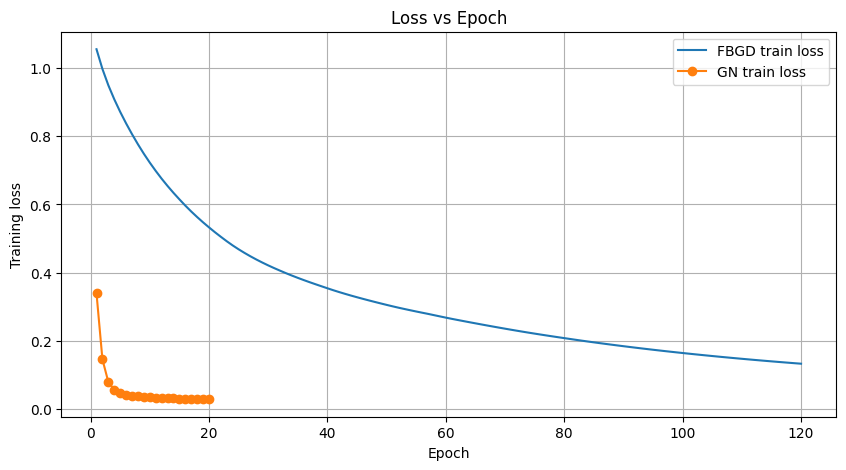

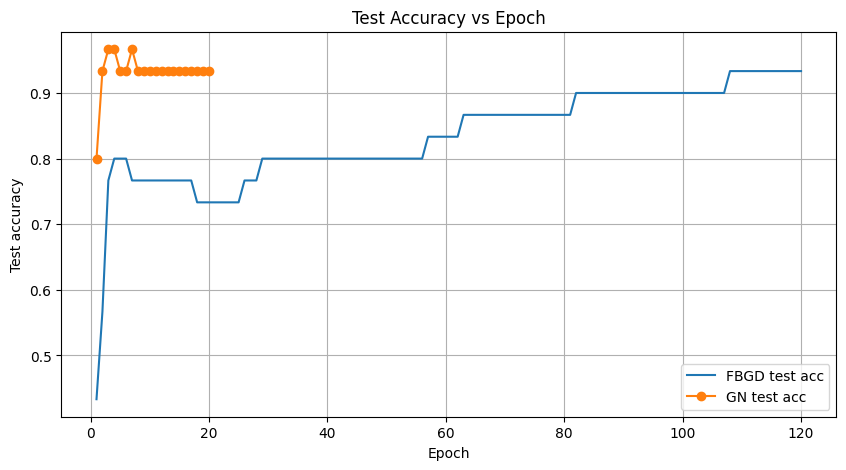

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(fbgd_hist['epoch'], fbgd_hist['train_loss'], label='FBGD train loss')
plt.plot(gn_hist['epoch'], gn_hist['train_loss'], marker='o', label='GN train loss')
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title('Loss vs Epoch')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(fbgd_hist['epoch'], fbgd_hist['test_acc'], label='FBGD test acc')
plt.plot(gn_hist['epoch'], gn_hist['test_acc'], marker='o', label='GN test acc')
plt.xlabel('Epoch')
plt.ylabel('Test accuracy')
plt.title('Test Accuracy vs Epoch')
plt.grid(True)
plt.legend()
plt.show()
